# Task 04 – Supervised Classification / Regression Modeling & Tuning

## Objective
Train and compare multiple supervised classification models on the cleaned Adult Income dataset, optimize their hyperparameters using stratified cross-validation, evaluate them with classification metrics, select a champion model, and serialize the final model.

### Dataset
`cleaned_adult_income.csv`

### Target
`income`

- `0` → `<=50K`
- `1` → `>50K`

### Required proof
- At least 4 distinct model architectures
- Hyperparameter optimization with GridSearchCV
- Stratified K-Fold cross-validation
- Model comparison table
- Precision, Recall, F1-Score, ROC-AUC
- Confusion matrices
- ROC-AUC curves
- Champion model
- Serialized `.joblib` model


## 1. Install / import libraries

Run the next cell first. If XGBoost or LightGBM is not installed in your environment, the installation cell will install them.

In [9]:
# Run this cell only if XGBoost / LightGBM are missing.
# Uncomment the following line if needed:
%pip install xgboost lightgbm joblib seaborn

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

RANDOM_STATE = 42
print("Libraries imported successfully.")


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------------------------------ --------- 1.0/1.4 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 9.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully.


## 2. Load the cleaned dataset

In [10]:
DATA_PATH = "cleaned_adult_income.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0



Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


## 3. Check the target and data types

The target is `income`. The remaining columns are predictors.

The categorical columns will be one-hot encoded inside the modeling pipeline. Numeric columns will be imputed and scaled for Logistic Regression; tree-based models can also use the same preprocessing safely.

In [11]:
TARGET = "income"

print("Target distribution:")
print(df[TARGET].value_counts())
print("\nTarget proportions:")
print(df[TARGET].value_counts(normalize=True).round(4))

X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nNumeric features:", numeric_features)
print("\nCategorical features:", categorical_features)


Target distribution:
income
0    24720
1     7841
Name: count, dtype: int64

Target proportions:
income
0    0.7592
1    0.2408
Name: proportion, dtype: float64

Numeric features: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical features: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


## 4. Train / validation split

We keep a separate validation/test set that is not used during GridSearchCV. `stratify=y` preserves the class distribution in both sets.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (26048, 14)
X_test : (6513, 14)
y_train: (26048,)
y_test : (6513,)


## 5. Build the preprocessing pipeline

### Numeric features
- Missing-value imputation using the median
- Standard scaling

### Categorical features
- Missing-value imputation using the most frequent value
- One-hot encoding

Putting preprocessing inside the pipeline prevents data leakage during cross-validation.

In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Preprocessor and StratifiedKFold are ready.")


Preprocessor and StratifiedKFold are ready.


# 6. Baseline models

We train four distinct architectures:

1. Logistic Regression
2. Random Forest
3. XGBoost
4. LightGBM

The initial models give us a baseline before hyperparameter optimization.

In [14]:
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )
}

baseline_results = []

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

baseline_comparison = pd.DataFrame(baseline_results).sort_values(
    "ROC-AUC", ascending=False
).reset_index(drop=True)

display(baseline_comparison.round(4))


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.8743,0.7789,0.6671,0.7187,0.9304
1,LightGBM,0.8767,0.7802,0.6792,0.7262,0.9300
2,Random Forest,0.8580,0.7352,0.6409,0.6848,0.9082
3,Logistic Regression,0.8558,0.7406,0.6173,0.6734,0.9078


# 7. Hyperparameter Optimization

We use `GridSearchCV` with **Stratified K-Fold cross-validation**.

The scoring metric is **ROC-AUC**, because this is a binary classification problem and ROC-AUC evaluates the quality of probability ranking across classification thresholds.

In [17]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1.0, 10.0],
        "model__solver": ["liblinear", "lbfgs"]
    },
    "Random Forest": {
        "model__n_estimators": [150, 250],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    },
    "XGBoost": {
        "model__n_estimators": [150, 250],
        "model__max_depth": [3, 6],
        "model__learning_rate": [0.05, 0.1],
        "model__subsample": [0.8, 1.0]
    },
    "LightGBM": {
        "model__n_estimators": [150, 250],
        "model__num_leaves": [15, 31],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [-1, 10]
    }
}

best_estimators = {}
tuning_results = []

for name, model in baseline_models.items():
    print(f"\n{'='*70}")
    print(f"Tuning: {name}")
    print(f"{'='*70}")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    grid.fit(X_train, y_train)
    best_estimators[name] = grid.best_estimator_

    y_pred = grid.predict(X_test)
    y_prob = grid.predict_proba(X_test)[:, 1]

    tuning_results.append({
        "Model": name,
        "Best CV ROC-AUC": grid.best_score_,
        "Validation Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "Validation ROC-AUC": roc_auc_score(y_test, y_prob),
        "Best Parameters": grid.best_params_
    })

    print("Best CV ROC-AUC:", round(grid.best_score_, 4))
    print("Best Parameters:", grid.best_params_)

tuned_comparison = pd.DataFrame(tuning_results).sort_values(
    "Validation ROC-AUC", ascending=False
).reset_index(drop=True)

display(tuned_comparison.round(4))



Tuning: Logistic Regression
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best CV ROC-AUC: 0.905
Best Parameters: {'model__C': 1.0, 'model__solver': 'lbfgs'}

Tuning: Random Forest
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best CV ROC-AUC: 0.9159
Best Parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 250}

Tuning: XGBoost
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best CV ROC-AUC: 0.9277
Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 150, 'model__subsample': 1.0}

Tuning: LightGBM
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best CV ROC-AUC: 0.9266
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 10, 'model__n_estimators': 250, 'model__num_leaves': 15}


,Model,Best CV ROC-AUC,Validation Accuracy,Precision,Recall,F1-Score,Validation ROC-AUC,Best Parameters
0,XGBoost,0.9277,0.8789,0.7926,0.6728,0.7278,0.9314,"{'model__learning_rate': 0.1, 'model__max_dept..."
1,LightGBM,0.9266,0.8759,0.7844,0.6684,0.7218,0.9293,"{'model__learning_rate': 0.05, 'model__max_dep..."
2,Random Forest,0.9159,0.8690,0.7947,0.6148,0.6933,0.9208,"{'model__max_depth': 20, 'model__min_samples_l..."
3,Logistic Regression,0.9050,0.8558,0.7406,0.6173,0.6734,0.9078,"{'model__C': 1.0, 'model__solver': 'lbfgs'}"


# 8. Detailed evaluation of tuned models

This section reports Precision, Recall, F1-Score and ROC-AUC on the held-out validation/test set.

In [18]:
evaluation_rows = []

for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    evaluation_rows.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

evaluation_table = pd.DataFrame(evaluation_rows).sort_values(
    "ROC-AUC", ascending=False
).reset_index(drop=True)

display(evaluation_table.round(4))


,Model,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.7926,0.6728,0.7278,0.9314
1,LightGBM,0.7844,0.6684,0.7218,0.9293
2,Random Forest,0.7947,0.6148,0.6933,0.9208
3,Logistic Regression,0.7406,0.6173,0.6734,0.9078


# 9. Classification reports and confusion matrices


Logistic Regression
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.74      0.62      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513



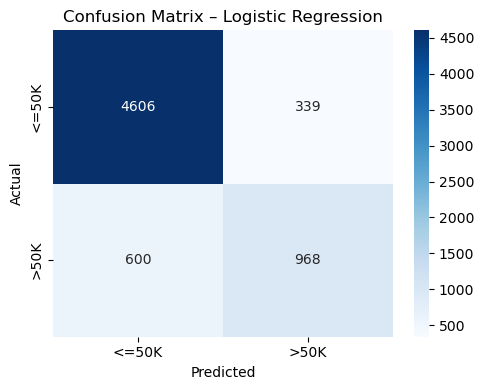


Random Forest
              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      4945
        >50K       0.79      0.61      0.69      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.78      0.81      6513
weighted avg       0.86      0.87      0.86      6513



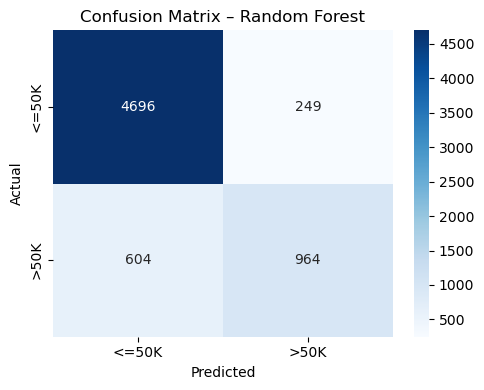


XGBoost
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      4945
        >50K       0.79      0.67      0.73      1568

    accuracy                           0.88      6513
   macro avg       0.85      0.81      0.82      6513
weighted avg       0.87      0.88      0.88      6513



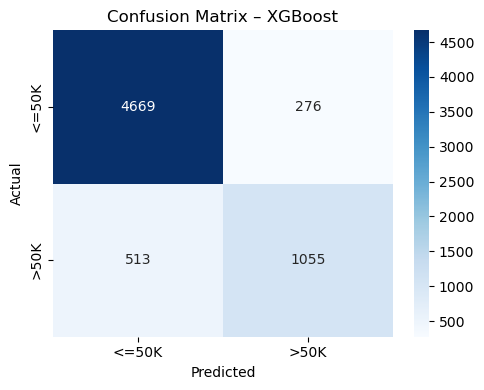


LightGBM
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      4945
        >50K       0.78      0.67      0.72      1568

    accuracy                           0.88      6513
   macro avg       0.84      0.81      0.82      6513
weighted avg       0.87      0.88      0.87      6513



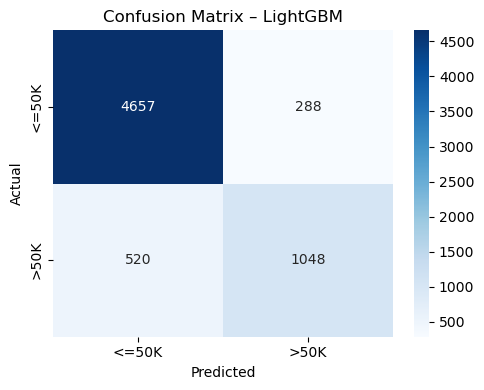

In [19]:
for name, model in best_estimators.items():
    y_pred = model.predict(X_test)

    print("\n" + "="*70)
    print(name)
    print("="*70)
    print(classification_report(
        y_test,
        y_pred,
        target_names=["<=50K", ">50K"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"]
    )
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


# 10. ROC-AUC curves

The ROC curve shows the trade-off between True Positive Rate and False Positive Rate across probability thresholds. The AUC summarizes the overall ranking performance.

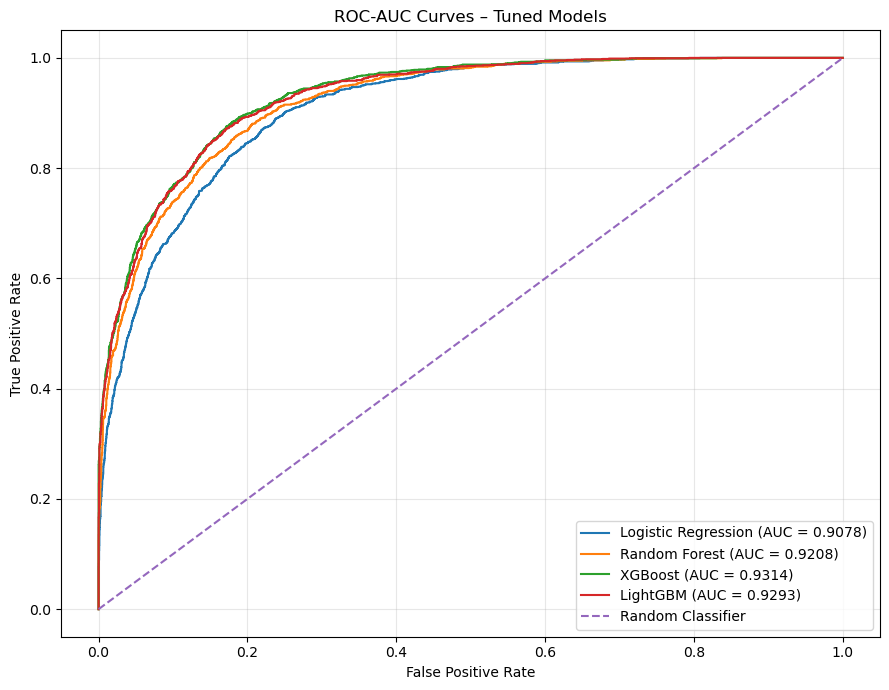

In [20]:
plt.figure(figsize=(9, 7))

for name, model in best_estimators.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves – Tuned Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 11. Select the Champion Model

The champion is selected using the **highest validation ROC-AUC**. Precision, Recall and F1-Score are also retained in the comparison table so the final choice can be interpreted from multiple perspectives.

In [21]:
champion_name = evaluation_table.iloc[0]["Model"]
champion_model = best_estimators[champion_name]

champion_row = evaluation_table.iloc[0]

print("Champion Model:", champion_name)
print("Precision:", round(champion_row["Precision"], 4))
print("Recall:", round(champion_row["Recall"], 4))
print("F1-Score:", round(champion_row["F1-Score"], 4))
print("ROC-AUC:", round(champion_row["ROC-AUC"], 4))


Champion Model: XGBoost
Precision: 0.7926
Recall: 0.6728
F1-Score: 0.7278
ROC-AUC: 0.9314


# 12. Save the Champion Model

The complete pipeline is saved, including preprocessing and the trained model. This is important because the same preprocessing must be applied when the model is used on future data.

In [22]:
MODEL_PATH = "champion_adult_income_model.joblib"

joblib.dump(champion_model, MODEL_PATH)

print(f"Champion model saved to: {os.path.abspath(MODEL_PATH)}")
print("File size (KB):", round(os.path.getsize(MODEL_PATH) / 1024, 2))


Champion model saved to: C:\Users\suren\RabTech\champion_adult_income_model.joblib
File size (KB): 415.07


# 13. Test the serialized model

Reload the `.joblib` file and confirm that it produces the same predictions.

In [23]:
loaded_model = joblib.load(MODEL_PATH)

loaded_pred = loaded_model.predict(X_test)
loaded_prob = loaded_model.predict_proba(X_test)[:, 1]

print("Reloaded model:", type(loaded_model).__name__)
print("Reloaded ROC-AUC:", round(roc_auc_score(y_test, loaded_prob), 4))
print("Predictions match original:",
      np.array_equal(loaded_pred, champion_model.predict(X_test)))


Reloaded model: Pipeline
Reloaded ROC-AUC: 0.9314
Predictions match original: True


# 14. Final model comparison

This table is the main proof for model comparison and champion selection.

In [24]:
final_comparison = evaluation_table.copy()
display(final_comparison.round(4))

final_comparison.to_csv(
    "task04_model_comparison.csv",
    index=False
)

print("Model comparison table saved as task04_model_comparison.csv")


,Model,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.7926,0.6728,0.7278,0.9314
1,LightGBM,0.7844,0.6684,0.7218,0.9293
2,Random Forest,0.7947,0.6148,0.6933,0.9208
3,Logistic Regression,0.7406,0.6173,0.6734,0.9078


Model comparison table saved as task04_model_comparison.csv


# 15. Conclusion

### Completed requirements

- [x] Trained at least 4 distinct classification architectures
- [x] Logistic Regression
- [x] Random Forest
- [x] XGBoost
- [x] LightGBM
- [x] Hyperparameter optimization with GridSearchCV
- [x] Stratified K-Fold cross-validation
- [x] Precision
- [x] Recall
- [x] F1-Score
- [x] ROC-AUC
- [x] Confusion matrices
- [x] ROC-AUC curves
- [x] Champion model selection
- [x] Champion model serialized as `.joblib`
- [x] Model comparison table saved as CSV

### Final interpretation

The champion model is selected from the held-out validation performance using ROC-AUC. The serialized pipeline contains both preprocessing and the trained model, so it can be reused later without manually repeating the preprocessing steps.
